# Tutorial 1 — The Assignment Problem

**What you will learn**
- What the linear assignment problem (LAP) is and where it appears
- Why finding the best assignment by brute force is impractical beyond ~10 items
- How to represent an assignment problem as a cost matrix
- How to visualise an assignment as a bipartite graph
- How to solve your first LAP with `torchmatch.assignment.solve`

**Prerequisites** — Python, NumPy basics, familiarity with PyTorch tensors.
No prior knowledge of combinatorial optimisation is assumed.

In [1]:
%matplotlib inline
import math
from itertools import permutations

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchmatch
from scipy.optimize import linear_sum_assignment  # reference solver

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
rng = np.random.default_rng(42)
print("torchmatch", torchmatch.__version__, "| torch", torch.__version__)

torchmatch 1.0.0 | torch 2.11.0+cu128


## 1  A concrete example: taxi dispatch

Three taxis wait at different spots in a city.  Three passengers need rides.
The **cost matrix** `C[i, j]` holds the travel time (in minutes) from taxi
`i` to passenger `j`.  We want to send each taxi to exactly one passenger
and minimise **total** travel time.

This is the **linear assignment problem (LAP)**: given a cost matrix, find
the one-to-one assignment of rows to columns with minimum total cost.

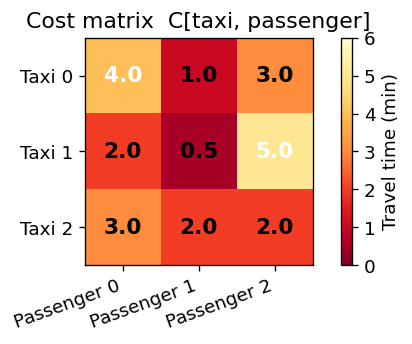

In [2]:
# rows = taxis, columns = passengers
C = np.array(
    [
        [4.0, 1.0, 3.0],  # taxi 0: 4 min to p0, 1 min to p1, 3 min to p2
        [2.0, 0.5, 5.0],  # taxi 1: very close to p1
        [3.0, 2.0, 2.0],  # taxi 2: moderate distance to all
    ],
    dtype=np.float32,
)

labels_row = ["Taxi 0", "Taxi 1", "Taxi 2"]
labels_col = ["Passenger 0", "Passenger 1", "Passenger 2"]

fig, ax = plt.subplots(figsize=(5, 3))
im = ax.imshow(C, cmap="YlOrRd_r", vmin=0, vmax=6)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels_col, rotation=20, ha="right")
ax.set_yticklabels(labels_row)
plt.colorbar(im, ax=ax, label="Travel time (min)")
for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            f"{C[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="white" if C[i, j] > 3 else "black",
        )
ax.set_title("Cost matrix  C[taxi, passenger]")
plt.tight_layout()
plt.show()

### Visualising the problem as a bipartite graph

An assignment problem always has this structure: two disjoint groups of
items (taxis on the left, passengers on the right), with a potential
connection — and a cost — between every item in the left group and every
item in the right group.  A valid assignment picks exactly one edge per
left node and exactly one edge per right node (a perfect matching).

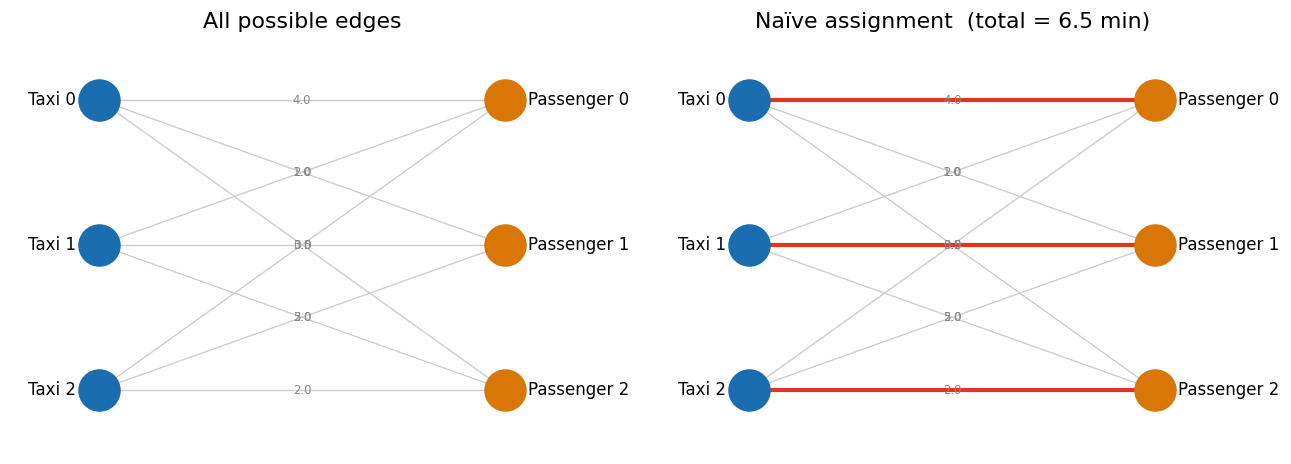

In [3]:
def draw_bipartite(ax, left_labels, right_labels, matching=None, costs=None, title=""):
    n = len(left_labels)
    left_x, right_x = 0.15, 0.85
    left_ys = np.linspace(0.85, 0.15, n)
    right_ys = np.linspace(0.85, 0.15, n)

    # all edges (grey, thin)
    for i, ly in enumerate(left_ys):
        for j, ry in enumerate(right_ys):
            ax.plot([left_x, right_x], [ly, ry], color="#cccccc", lw=0.8, zorder=1)
            if costs is not None:
                mx, my = (left_x + right_x) / 2, (ly + ry) / 2
                ax.text(
                    mx,
                    my,
                    f"{costs[i, j]:.1f}",
                    fontsize=7,
                    ha="center",
                    va="center",
                    color="#888888",
                )

    # matched edges (red, thick)
    if matching is not None:
        for i, j in enumerate(matching):
            ax.plot(
                [left_x, right_x],
                [left_ys[i], right_ys[j]],
                color="#E03520",
                lw=2.5,
                zorder=2,
            )

    # nodes
    for i, (y, lbl) in enumerate(zip(left_ys, left_labels)):
        ax.scatter(left_x, y, s=600, color="#1a6daf", zorder=3)
        ax.text(left_x - 0.04, y, lbl, ha="right", va="center", fontsize=10)
    for j, (y, lbl) in enumerate(zip(right_ys, right_labels)):
        ax.scatter(right_x, y, s=600, color="#d97706", zorder=3)
        ax.text(right_x + 0.04, y, lbl, ha="left", va="center", fontsize=10)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
draw_bipartite(axes[0], labels_row, labels_col, costs=C, title="All possible edges")
# naive sequential assignment: taxi 0 → passenger 0, taxi 1 → passenger 1, etc.
naive = [0, 1, 2]
cost_naive = sum(C[i, j] for i, j in enumerate(naive))
draw_bipartite(
    axes[1],
    labels_row,
    labels_col,
    matching=naive,
    costs=C,
    title=f"Naïve assignment  (total = {cost_naive:.1f} min)",
)
plt.tight_layout()
plt.show()

The naïve assignment (each taxi goes to the passenger with the same index)
gives a higher total cost than necessary.  Can we do better?

## 2  Why brute force does not scale

For `n` taxis and `n` passengers there are `n!` (n-factorial) possible
assignments.  For small problems we can check all of them; large problems defeat this approach.

In [4]:
def brute_force_lap(C):
    """Return the optimal assignment by checking every permutation."""
    n = C.shape[0]
    best_cost, best_perm = float("inf"), None
    for perm in permutations(range(n)):
        cost = sum(C[i, perm[i]] for i in range(n))
        if cost < best_cost:
            best_cost, best_perm = cost, list(perm)
    return best_perm, best_cost


opt_perm, opt_cost = brute_force_lap(C)
print(f"Optimal assignment : taxi {[i for i in range(3)]} → passenger {opt_perm}")
print(f"Optimal total cost : {opt_cost:.1f} min  (naïve was {cost_naive:.1f} min)")

Optimal assignment : taxi [0, 1, 2] → passenger [1, 0, 2]
Optimal total cost : 5.0 min  (naïve was 6.5 min)


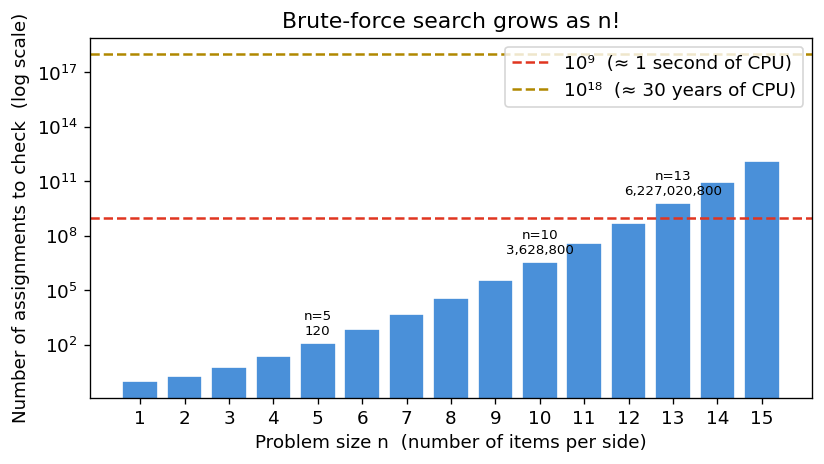

n=10 → 3,628,800 permutations
n=20 → 2,432,902,008,176,640,000 permutations  (infeasible)


In [5]:
# Show how n! explodes
ns = list(range(1, 16))
factorials = [math.factorial(n) for n in ns]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ns, factorials, color="#4a90d9", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Problem size n  (number of items per side)")
ax.set_ylabel("Number of assignments to check  (log scale)")
ax.set_title("Brute-force search grows as n!")
ax.axhline(1e9, color="#E03520", ls="--", lw=1.5, label="10⁹  (≈ 1 second of CPU)")
ax.axhline(1e18, color="#b08800", ls="--", lw=1.5, label="10¹⁸  (≈ 30 years of CPU)")
ax.legend()
for i, (n, f) in enumerate(zip(ns, factorials)):
    if n in (5, 10, 13):
        ax.text(n, f * 2, f"n={n}\n{f:,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(ns)
plt.tight_layout()
plt.show()

print(f"n=10 → {math.factorial(10):,} permutations")
print(f"n=20 → {math.factorial(20):,} permutations  (infeasible)")

Efficient algorithms (like the Hungarian method or Jonker-Volgenant) solve
the LAP in **O(n³)** time — many orders of magnitude faster than brute force.

| n   | Brute force   | O(n³) |
|-----|--------------|-------|
| 10  | 3.6 million  | 1 000 |
| 100 | ~10¹⁵⁷       | 10⁶   |
| 1000| ∞            | 10⁹   |

## 3  Solving with torchmatch

`torchmatch.assignment.solve` takes a 2-D (or 3-D batched) cost tensor and
returns an integer tensor of length `n_rows`: element `i` is the column
assigned to row `i`.

In [6]:
cost_t = torch.tensor(C)

row_to_col = torchmatch.assignment.solve(cost_t)
print("row_to_col :", row_to_col.tolist())
print("Optimal assignment:")
for taxi, passenger in enumerate(row_to_col.tolist()):
    print(f"  taxi {taxi}  →  passenger {passenger}  (cost {C[taxi, passenger]:.1f})")
total = cost_t[torch.arange(3), row_to_col].sum().item()
print(f"Total cost: {total:.1f}")

row_to_col : [1, 0, 2]
Optimal assignment:
  taxi 0  →  passenger 1  (cost 1.0)
  taxi 1  →  passenger 0  (cost 2.0)
  taxi 2  →  passenger 2  (cost 2.0)
Total cost: 5.0


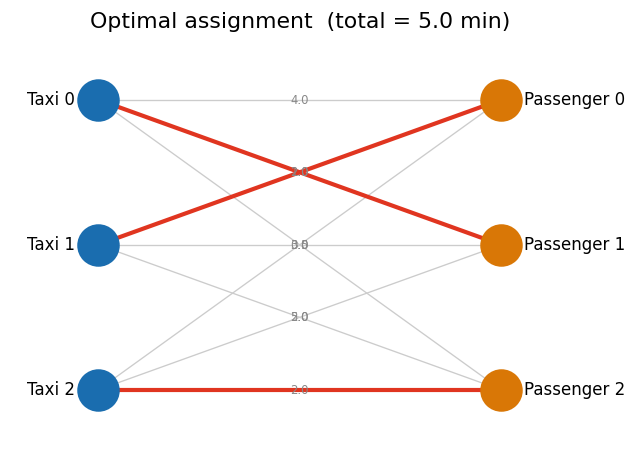

In [7]:
# Visualise the optimal matching
fig, ax = plt.subplots(figsize=(5.5, 4))
draw_bipartite(
    ax,
    labels_row,
    labels_col,
    matching=row_to_col.tolist(),
    costs=C,
    title=f"Optimal assignment  (total = {total:.1f} min)",
)
plt.tight_layout()
plt.show()

## 4  Rectangular problems and forbidden edges

Real problems are often **rectangular** (more items on one side than the
other) or have **forbidden pairs** (some assignments are infeasible).
torchmatch handles both.

In [8]:
# More taxis than passengers — some taxis stay idle (get assigned -1)
C_rect = torch.tensor(
    [
        [4.0, 1.0],
        [2.0, 0.5],
        [3.0, 2.0],
        [1.5, 3.5],  # extra taxi
    ],
    dtype=torch.float32,
)

result = torchmatch.assignment.solve(C_rect)
print("Rectangular (4 taxis, 2 passengers):", result.tolist())
print(" -1 means the taxi is unassigned")

# Forbidden edges: set to +inf
C_gated = torch.tensor(
    [
        [4.0, float("inf"), 3.0],  # taxi 0 cannot reach passenger 1
        [float("inf"), 0.5, 5.0],  # taxi 1 cannot reach passenger 0
        [3.0, 2.0, float("inf")],  # taxi 2 cannot reach passenger 2
    ],
    dtype=torch.float32,
)

result_gated = torchmatch.assignment.solve(C_gated)
print("\nWith forbidden edges (+inf):", result_gated.tolist())
total_gated = sum(
    C_gated[i, j].item()
    for i, j in enumerate(result_gated.tolist())
    if j >= 0 and C_gated[i, j] != float("inf")
)
print(f"Total feasible cost: {total_gated:.1f}")

Rectangular (4 taxis, 2 passengers): [-1, 1, -1, 0]
 -1 means the taxi is unassigned

With forbidden edges (+inf): [2, 1, 0]
Total feasible cost: 6.5


## 5  Comparing to scipy

torchmatch produces the same optimal assignments as SciPy's reference
solver, but stays inside the PyTorch ecosystem (no NumPy round-trip),
supports batching, and runs on GPU.

In [9]:
# Verify correctness against scipy
scipy_rows, scipy_cols = linear_sum_assignment(C)
scipy_assignment = scipy_cols.tolist()
tm_assignment = torchmatch.assignment.solve(torch.tensor(C)).tolist()

print("scipy assignment :", scipy_assignment)
print("torchmatch       :", tm_assignment)
assert scipy_assignment == tm_assignment, "Mismatch!"
print("✓ Results match")

scipy assignment : [1, 0, 2]
torchmatch       : [1, 0, 2]
✓ Results match


## Summary

- The **linear assignment problem** finds the minimum-cost one-to-one
  mapping between two sets of items.
- Brute force is O(n!) and impractical for n > ~10.
- `torchmatch.assignment.solve(cost)` solves in O(n³) using
  hardware-optimised kernels (AVX2 on CPU, CUDA on GPU).
- Rectangular inputs and forbidden edges (`+inf`) are handled natively;
  unassigned rows return `-1`.

**Next**: [Tutorial 2 — Backends and Batching](02_backends_and_batching.ipynb)
explores the different solvers, when to choose each, and how to solve
thousands of problems at once.